# California Housing Model
---

In [303]:
# Importing the necessary modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

## Preprocessing the data

In [304]:
# Loading the data
data = pd.read_csv('data/housing.csv')

# Splitting the data
train_data, temp_data = train_test_split(
    data,
    test_size=.2,
    random_state=42
)

validation_data, test_data = train_test_split(
    temp_data,
    test_size=.5,
    random_state=42
)

# data information
print(data.info())
print(validation_data.shape)
print(test_data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
(2064, 10)
(2064, 10)


In [305]:
# Splitting the data between x and y labels
x_train = train_data.drop('median_house_value', axis=1)
y_train = train_data['median_house_value']

x_validation = validation_data.drop('median_house_value', axis=1)
y_validation = validation_data['median_house_value']

x_test = test_data.drop('median_house_value', axis=1)
y_test = test_data['median_house_value']

# getting the shapes of each dataset
print(x_train.shape)
print(y_train.shape)

print(x_validation.shape)
print(y_validation.shape)

print(x_test.shape)
print(y_test.shape)

(16512, 9)
(16512,)
(2064, 9)
(2064,)
(2064, 9)
(2064,)


## Imputation and One Hot Encoding

In [306]:
# Dividing the dataset for numerical and class categorical data
x_train_housing = x_train.drop('ocean_proximity', axis=1) # The Numerical data
x_train_proximity = x_train[['ocean_proximity']]

x_validation_housing = x_validation.drop('ocean_proximity', axis=1) # The Numerical data
x_validation_proximity = x_validation[['ocean_proximity']]

x_test_housing = x_test.drop('ocean_proximity', axis=1) # The Numerical data
x_test_proximity = x_test[['ocean_proximity']]

# NOTE: using double square brackets in proximity variables as in OneHotEncoder it requires a dataframe and not a series (2-D)
print(x_test_proximity.shape)

(2064, 1)


In [307]:
# Imputation
imputer = SimpleImputer(strategy='median')

x_train_housing_tr = imputer.fit_transform(x_train_housing)
x_validation_housing_tr = imputer.transform(x_validation_housing)
x_test_housing_tr = imputer.transform(x_test_housing)

print(type(x_train_housing_tr))
# converting imputed data in pandas dataframe

print(type(x_train_housing.index))

x_train_housing_tr = pd.DataFrame(
    x_train_housing_tr,
    columns=x_train_housing.columns,
    index=x_train_housing.index
)

x_validation_housing_tr = pd.DataFrame(
    x_validation_housing_tr,
    columns=x_validation_housing.columns,
    index=x_validation_housing.index
)

x_test_housing_tr = pd.DataFrame(
    x_test_housing_tr,
    columns=x_test_housing.columns,
    index=x_test_housing.index
)
print(type(x_train_housing_tr))
print(x_test_housing_tr.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.frame.DataFrame'>
(2064, 8)


In [308]:
# One Hot Encoding of the Data
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(x_train_proximity)
encoded_validation = encoder.transform(x_validation_proximity)
encoded_test = encoder.transform(x_test_proximity)

x_train_proximity = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(),
    index=x_train.index
)

x_validation_proximity = pd.DataFrame(
    encoded_validation,
    columns=encoder.get_feature_names_out(),
    index=x_validation.index
)

x_test_proximity = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(),
    index=x_test.index
)
print(type(x_train_proximity))
print(type(x_validation_proximity))
print(type(x_test_proximity))
print(x_test_proximity.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(2064, 5)


## Standardization and Concatenation

In [309]:
# Normalizing the data
scaler = StandardScaler()

x_train_normalized = scaler.fit_transform(x_train_housing_tr)
x_validation_normalized = scaler.transform(x_validation_housing_tr)
x_test_normalized = scaler.transform(x_test_housing_tr)

print(type(x_train_normalized))
# converting to Pandas DataFrames
x_train_normalized = pd.DataFrame(
    x_train_normalized,
    columns=x_train_housing_tr.columns,
    index=x_train_housing_tr.index
)
x_validation_normalized = pd.DataFrame(
    x_validation_normalized,
    columns=x_validation_housing_tr.columns,
    index=x_validation_housing_tr.index
)
x_test_normalized = pd.DataFrame(
    x_test_normalized,
    columns=x_test_housing_tr.columns,
    index=x_test_housing_tr.index
)
print(type(x_train_normalized))
print(x_test_normalized.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(2064, 8)


In [310]:
# Concatenation of Data
x_train_merged = pd.concat(
    [x_train_normalized, x_train_proximity],
    axis=1
)

x_validation_merged = pd.concat(
    [x_validation_normalized, x_validation_proximity],
    axis=1
)

x_test_merged = pd.concat(
    [x_test_normalized, x_test_proximity],
    axis=1
)

print(x_train_merged.info())
print(x_test_merged.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   16512 non-null  float64
 1   latitude                    16512 non-null  float64
 2   housing_median_age          16512 non-null  float64
 3   total_rooms                 16512 non-null  float64
 4   total_bedrooms              16512 non-null  float64
 5   population                  16512 non-null  float64
 6   households                  16512 non-null  float64
 7   median_income               16512 non-null  float64
 8   ocean_proximity_<1H OCEAN   16512 non-null  float64
 9   ocean_proximity_INLAND      16512 non-null  float64
 10  ocean_proximity_ISLAND      16512 non-null  float64
 11  ocean_proximity_NEAR BAY    16512 non-null  float64
 12  ocean_proximity_NEAR OCEAN  16512 non-null  float64
dtypes: float64(13)
memory usage: 1.8

## Final Stage Pre-Processing

In [311]:
# Final preprocessing

BATCH_SIZE = 32 # Defining the batch size

AUTOTUNE = tf.data.AUTOTUNE # For AUTOTUNE

# Preparing the final data for fitting (training)

x_train_final = (
    tf.data.Dataset.from_tensor_slices((x_train_merged, y_train))
    .shuffle(buffer_size=len(x_train_merged), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

x_validation_final = (
    tf.data.Dataset.from_tensor_slices((x_validation_merged, y_validation))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


x_test_final = (
    tf.data.Dataset.from_tensor_slices((x_test_merged, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print(x_train_merged.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   16512 non-null  float64
 1   latitude                    16512 non-null  float64
 2   housing_median_age          16512 non-null  float64
 3   total_rooms                 16512 non-null  float64
 4   total_bedrooms              16512 non-null  float64
 5   population                  16512 non-null  float64
 6   households                  16512 non-null  float64
 7   median_income               16512 non-null  float64
 8   ocean_proximity_<1H OCEAN   16512 non-null  float64
 9   ocean_proximity_INLAND      16512 non-null  float64
 10  ocean_proximity_ISLAND      16512 non-null  float64
 11  ocean_proximity_NEAR BAY    16512 non-null  float64
 12  ocean_proximity_NEAR OCEAN  16512 non-null  float64
dtypes: float64(13)
memory usage: 1.8

## Model's Architecture

In [312]:
# defining the model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(13,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## compiling and Fitting (Training) the model

In [313]:
# configuring the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [316]:
# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [317]:
# fitting (training) the model
model_history = model.fit(
    x_train_final,
    validation_data=x_validation_final,
    epochs=500,
    callbacks=[early_stopping]
)

Epoch 1/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4165884160.0000 - mae: 45509.3516 - val_loss: 4515125760.0000 - val_mae: 46952.8203
Epoch 2/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4164425728.0000 - mae: 45451.7617 - val_loss: 4518760960.0000 - val_mae: 47110.0469
Epoch 3/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4162905856.0000 - mae: 45486.9062 - val_loss: 4515049472.0000 - val_mae: 47024.5312
Epoch 4/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4161129472.0000 - mae: 45437.9805 - val_loss: 4516078080.0000 - val_mae: 47052.2305
Epoch 5/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4158853632.0000 - mae: 45418.2812 - val_loss: 4513086464.0000 - val_mae: 47076.7148
Epoch 6/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4156721152.0000 - mae: 45455.6094 - val_loss: 4510006784.0000 - val_mae: 46967.1250
Epoch 7/500
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4156049408.0000 - mae: 45418.8164 - val_loss: 4509734912.0000 - val_m

In [318]:
# testing the model
model.evaluate(x_test_final)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3446361344.0000 - mae: 40314.2500  


[3446361344.0, 40314.25]

## Plotting the Graphs 📈

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


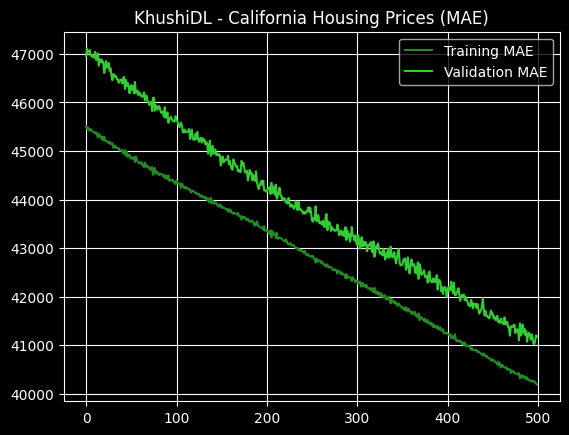

In [319]:
# Plotting the MAE [metric] (regression) graph
model_data = model_history.history
print(model_data.keys())

plt.style.use('dark_background')
plt.title('KhushiDL - California Housing Prices (MAE)')
plt.plot(model_data['mae'], label='Training MAE', color='forestgreen')
plt.plot(model_data['val_mae'], label='Validation MAE', color='limegreen')
# plt.plot(model_data['loss'], label='LOSS', marker='d', color='crimson')
plt.legend()
plt.grid(True)
plt.savefig('mae.png')

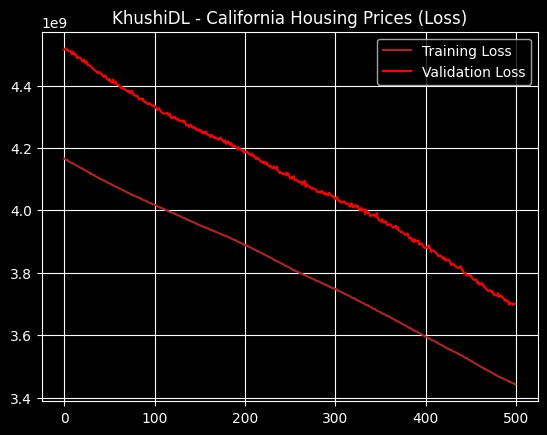

In [320]:
plt.title('KhushiDL - California Housing Prices (Loss)')
plt.plot(model_data['loss'], label='Training Loss', color='firebrick')
plt.plot(model_data['val_loss'], label='Validation Loss', color='red')
plt.legend()
plt.grid(True)
plt.savefig('loss.png')

## Saving the Model 🧠

In [321]:
model.save('KhushiDL_California_House_Prices_v2.keras')

In [322]:
# Predicting
for i in range(10):
  x = x_test_merged.iloc[i]
  y = y_test.iloc[i]
  prediction = model.predict(tf.expand_dims(x, axis=0))
  print('predicted:',prediction, '\tactual:', y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
predicted: [[241183.45]] 	actual: 238500.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
predicted: [[280132.06]] 	actual: 329700.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
predicted: [[161528.5]] 	actual: 95200.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
predicted: [[242450.38]] 	actual: 245100.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
predicted: [[98970.77]] 	actual: 64100.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
predicted: [[338577.84]] 	actual: 376600.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
predicted: [[243854.97]] 	actual: 230700.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
predicted: [[138392.38]] 	actual: 175200.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
predicted: [[506324.4]] 	actual: 416700.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
predicted: [[86844.71]] 	actual: 93800.0
